#  Bicycle Infrastructure EDA
**Task 1 – Bicycle Infrastructure Network Analysis**

### Objective
- Explore the bicycle infrastructure dataset.
- Assess data quality and completeness.
- Understand the spatial distribution of bicycle infrastructure.
- Calculate network statistics to support future spatial analysis.
- Prepare a cleaned dataset for integration with parking and traffic datasets.

# Import Libraries

In [3]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from pathlib import Path

# Improve plot appearance
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid")

# Load and Display Dataset

In [5]:
# ==========================================================
# Load Bicycle Infrastructure Dataset
# ==========================================================

# Location of the GeoJSON file
bike_path = Path("bicycle_infrastructure_network.geojson")

# Read the spatial dataset
bike_gdf = gpd.read_file(bike_path)

print("Dataset Loaded Successfully")

# ==========================================================
# Display Sample Records
# ==========================================================

# Display the first five records
bike_gdf.head()

Dataset Loaded Successfully


,OsmID,InfraType,Name,HwyType,Width,Hazards,DirRelToWay,DirCardinal,geometry
0,8957718,Protected bike lane (on-road),Queens Avenue,Residential,NaN,,Reverse,Westbound,"MULTILINESTRING ((144.9232 -37.77754, 144.9232..."
1,516834888,Basic painted lane,Stud Road Service Road,Residential,1.5,,Reverse,Northbound,"MULTILINESTRING ((145.24609 -37.84764, 145.246..."
2,643729142,Basic painted lane,Stud Road Service Road,Residential,1.5,,Reverse,Northbound,"MULTILINESTRING ((145.246 -37.84785, 145.24582..."
3,32328349,Basic painted lane,Peel Street North,Residential,NaN,,Reverse,Southbound,"MULTILINESTRING ((143.86394 -37.56201, 143.863..."
4,81129266,Basic painted lane,Humffray Street North,Tertiary,1.2,Parking,Reverse,Westbound,"MULTILINESTRING ((143.88292 -37.55455, 143.885..."


# Dataset Information

In [6]:
# ==========================================================
# Dataset Overview
# ==========================================================

print("Shape of Dataset")
print(bike_gdf.shape)

print("\nColumns")
print(bike_gdf.columns)

print("\nCoordinate Reference System")
print(bike_gdf.crs)

print("\nGeometry Types")
print(bike_gdf.geom_type.value_counts())

Shape of Dataset
(55705, 9)

Columns
Index(['OsmID', 'InfraType', 'Name', 'HwyType', 'Width', 'Hazards',
       'DirRelToWay', 'DirCardinal', 'geometry'],
      dtype='object')

Coordinate Reference System
EPSG:4326

Geometry Types
MultiLineString    55705
Name: count, dtype: int64


# Missing Values

In [7]:
# ==========================================================
# Missing Value Analysis
# ==========================================================

missing = bike_gdf.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

Width          24934
Name           21858
DirCardinal      370
dtype: int64


# Duplicate Records

In [8]:
# ==========================================================
# Duplicate Record Check
# ==========================================================

duplicates = bike_gdf.duplicated().sum()

print(f"Duplicate Records : {duplicates}")

Duplicate Records : 25


# Geometry Summary

In [9]:
# ==========================================================
# Geometry Summary
# ==========================================================

print(bike_gdf.geometry.describe())

count                                                 55705
unique                                                47870
top       MULTILINESTRING ((144.9495384 -37.3104979, 144...
freq                                                      4
Name: geometry, dtype: object


# Calculate Network Length

In [14]:
# ==========================================================
# Calculate Infrastructure Length
# ==========================================================

# Convert to projected CRS if required
if bike_gdf.crs != "EPSG:7899":
    bike_gdf = bike_gdf.to_crs("EPSG:7899")
# ==========================================================
# Display Coordinate Reference System (CRS)
# ==========================================================

print("Coordinate Reference System (CRS):")
print(bike_gdf.crs)
# Calculate segment length in metres
bike_gdf["length_m"] = bike_gdf.geometry.length

# Convert to kilometres
bike_gdf["length_km"] = bike_gdf["length_m"] / 1000

bike_gdf[["length_m","length_km"]].head()

Coordinate Reference System (CRS):
EPSG:7899


,length_m,length_km
0,345.096014,0.345096
1,24.702181,0.024702
2,241.460125,0.241460
3,167.343407,0.167343
4,1755.597451,1.755597


# Length Distribution

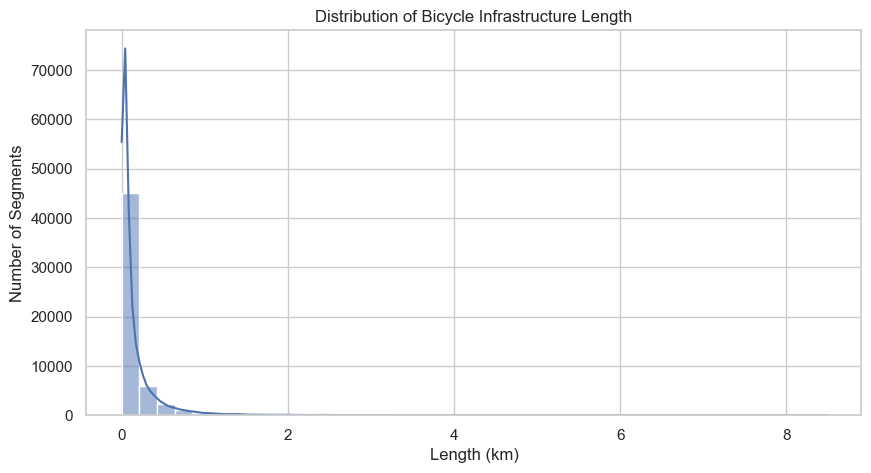

In [15]:
# ==========================================================
# Distribution of Bicycle Segment Lengths
# ==========================================================

plt.figure(figsize=(10,5))

sns.histplot(
    bike_gdf["length_km"],
    bins=40,
    kde=True
)

plt.title("Distribution of Bicycle Infrastructure Length")

plt.xlabel("Length (km)")

plt.ylabel("Number of Segments")

plt.show()

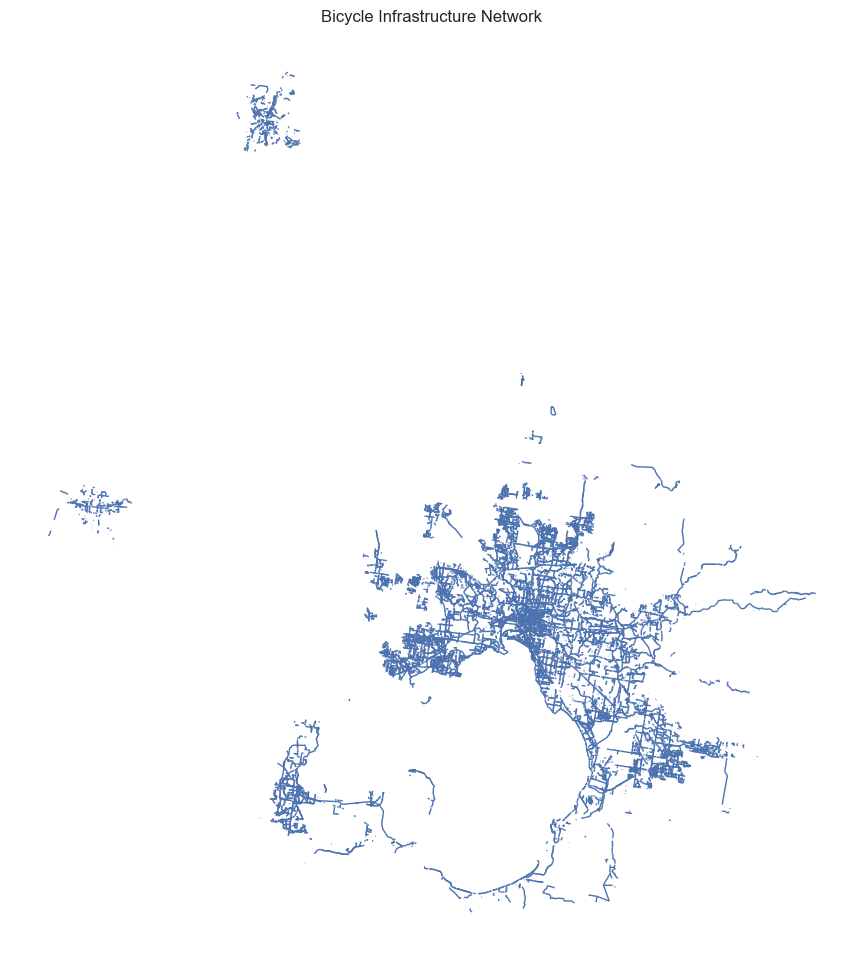

In [16]:
# ==========================================================
# Spatial Distribution of Bicycle Infrastructure
# ==========================================================

fig, ax = plt.subplots(figsize=(12,12))

bike_gdf.plot(
    ax=ax,
    linewidth=1
)

plt.title("Bicycle Infrastructure Network")

plt.axis("off")

plt.show()

In [17]:
# ==========================================================
# Spatial Extent
# ==========================================================

print(bike_gdf.total_bounds)

[2385999.59676289 2343578.00607944 2563607.29829051 2538023.8223427 ]


In [20]:
# ==========================================================
# Save Processed Dataset
# ==========================================================

output_path = "Victoria-Urban-Planning/data/processed/bicycle_infrastructure_network_clean.geojson"

bike_gdf.to_file(
    output_path,
    driver="GeoJSON"
)

print("Processed dataset saved successfully.")

Processed dataset saved successfully.
